EpiConfig default_influenza_point_prediction loaded

==                   nodelstm                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: DeepData(x=(400, 23, 4), y=(400, 1))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.8738   |   1.4219   |    v     |           |
|  002  |   0.7479   |   1.2425   |    v     |           |
|  003  |   0.6922   |   1.0752   |    v     |           |
|  004  |   0.6357   |   0.8759   |    v     |           |
|  005  |   0.5841   |   0.6951   |    v     |           |
|  006  |   0.5505   |   0.6144   |    v     |           |
|  007  |   0.5101   |   0.5620   |    v     |           |
|  008  |   0.4831   |   0.5301   |    v     |           |
|  009  |   0.4605   |   0.5035   |    v     |           |
|  010  |   0.4482   |   0.4880   |    v     |           |
|  011  |   0.4392   |   0.4745   |    v     |           |
|  012  |   0.4330   |   0.464

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3860
trained ✓


Forecasting test: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 1982.75it/s]

Test loss: 0.6274
forecasted ✓


LSTMModel(name='nodelstm')

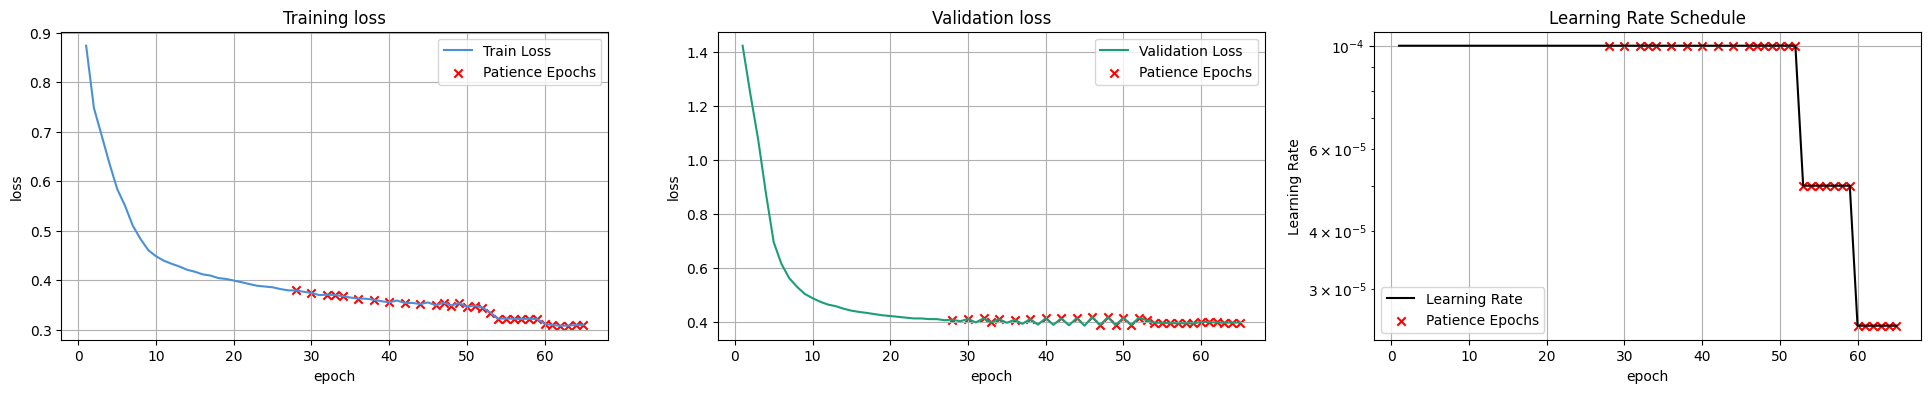

In [1]:
from src.dataloading import EpiConfig, EpiDataOrchestrator
from src.dataloading import BaseLineDataLoaderManager
from src.models import LSTMModel, GATv2LSTMModel

epiconfig= EpiConfig.load_config('default_influenza_point_prediction')
data_orch= EpiDataOrchestrator(epiconfig).build()

from src.dataloading import DeepDataLoaderManager, GraphDataLoaderManager

n_epochs        = 500
lr              = 0.0001
min_delta       = 0.0001
loss            = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

dl = DeepDataLoaderManager(data_orch).build()
gdl= GraphDataLoaderManager(data_orch).retrieve_static_graph('geographical_neighbors1').build()

lstm = LSTMModel(dl,verbose = 2)
lstm.set_model_hparams()
lstm.set_global_hparams(**global_hparams)
lstm.train()
lstm.forecast('test')

In [ ]:
gatv2lstm = GATv2LSTMModel(gdl,verbose = 2)
gatv2lstm.set_model_hparams()
gatv2lstm.set_global_hparams(**global_hparams)
gatv2lstm.train()
gatv2lstm.forecast('test')


==                gatv2lstmmodel                ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 23, 4), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.8934   |   1.5070   |    v     |           |
|  002  |   0.6308   |   0.8714   |    v     |           |
|  003  |   0.5538   |   0.6919   |    v     |           |
|  004  |   0.5197   |   0.6220   |    v     |           |
|  005  |   0.4894   |   0.5440   |    v     |           |
|  006  |   0.4701   |   0.5374   |    v     |           |
|  007  |   0.4535   |   0.4728   |    v     |           |
|  008  |   0.4403   |   0.4853   |          |   1/20    |
|  009  |   0.4271   |   0.4356   |    v     |           |
|  010  |   0.4230   |   0.4494   |          |   1/20    |
|  011  |   0.4114   |   0.4077   |    v     |           |
|  012  |   0.4087   |   0.4309   |   


==              gatv2lstmmodel_ig               ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 23, 4), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.8073   |   1.2459   |    v     |           |
|  002  |   0.5897   |   0.8396   |    v     |           |
|  003  |   0.5189   |   0.6730   |    v     |           |
|  004  |   0.4924   |   0.6192   |    v     |           |
|  005  |   0.4733   |   0.5710   |    v     |           |
|  006  |   0.4658   |   0.5498   |    v     |           |
|  007  |   0.4560   |   0.5282   |    v     |           |
|  008  |   0.4495   |   0.5023   |    v     |           |
|  009  |   0.4439   |   0.5032   |          |   1/20    |
|  010  |   0.4326   |   0.4653   |    v     |           |
|  011  |   0.4300   |   0.4857   |          |   1/20    |
|  012  |   0.4203   |   0.4339   |    v

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 20 epochs
Restored model from best validation loss: 0.3732
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 265.40it/s]

Test loss: 0.5569
forecasted ✓


GATv2LSTMModel(name='gatv2lstmmodel_ig')

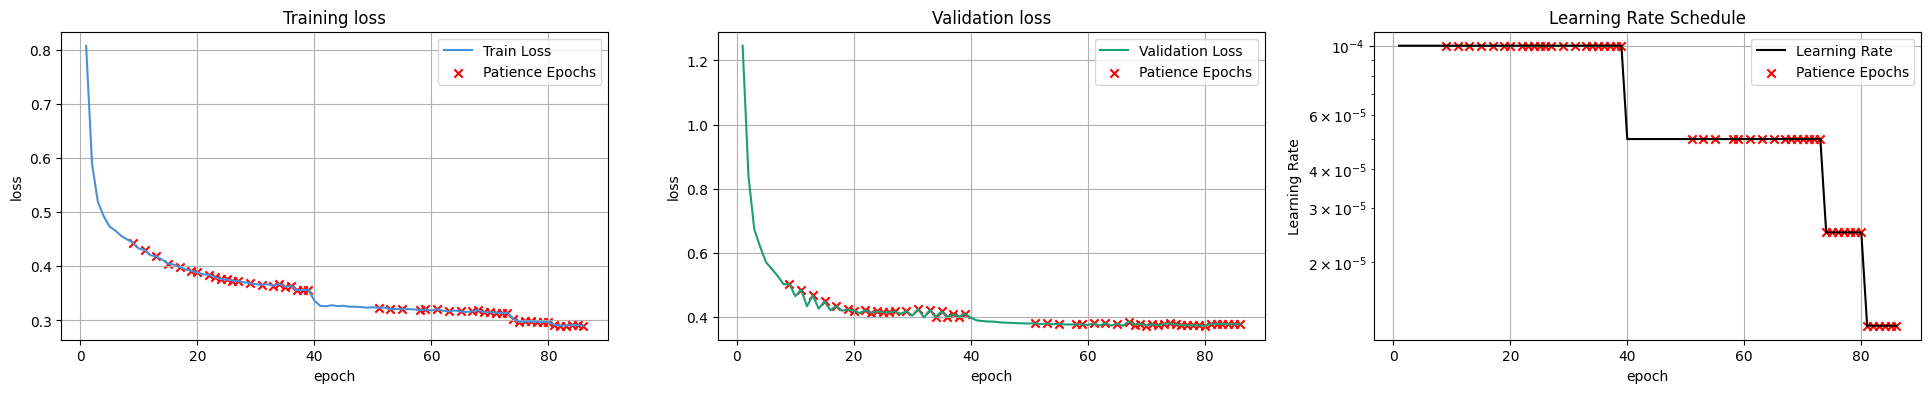

In [24]:
gdlc= GraphDataLoaderManager(data_orch).retrieve_static_graph('identity_graph').build()
gatv2lstmc = GATv2LSTMModel(gdlc,verbose = 2, name = 'gatv2lstmmodel ig')
gatv2lstmc.set_model_hparams()
gatv2lstmc.set_global_hparams(**global_hparams)
gatv2lstmc.train()
gatv2lstmc.forecast('test')

In [8]:
from src.models import PersistenceModel, ClimateologyModel, ConstantModel, ClimaScaleModel
baseline_data           = BaseLineDataLoaderManager(data_orch)
constant_predictor      = ConstantModel(baseline_data)
persistence_predictor   = PersistenceModel(baseline_data)
climateology            = ClimateologyModel(baseline_data)
climascale              = ClimaScaleModel(baseline_data)

node_sample = 26

constant_predictor.set_model_hparams(0)
constant_predictor.train()
constant_predictor.forecast('test')

persistence_predictor.train()
persistence_predictor.forecast('test')

climateology.train()
climateology.forecast('test')

climascale.train()
climascale.forecast('test')

ClimaScaleModel(name='climascale_model')

In [25]:
from src.evaluation import Evaluator
e = Evaluator([persistence_predictor, climateology, climascale] + [lstm, gatv2lstm, gatv2lstmc]).add_evaluation(dataset = 'test')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2400/2400 [00:02<00:00, 813.60it/s]


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:139: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


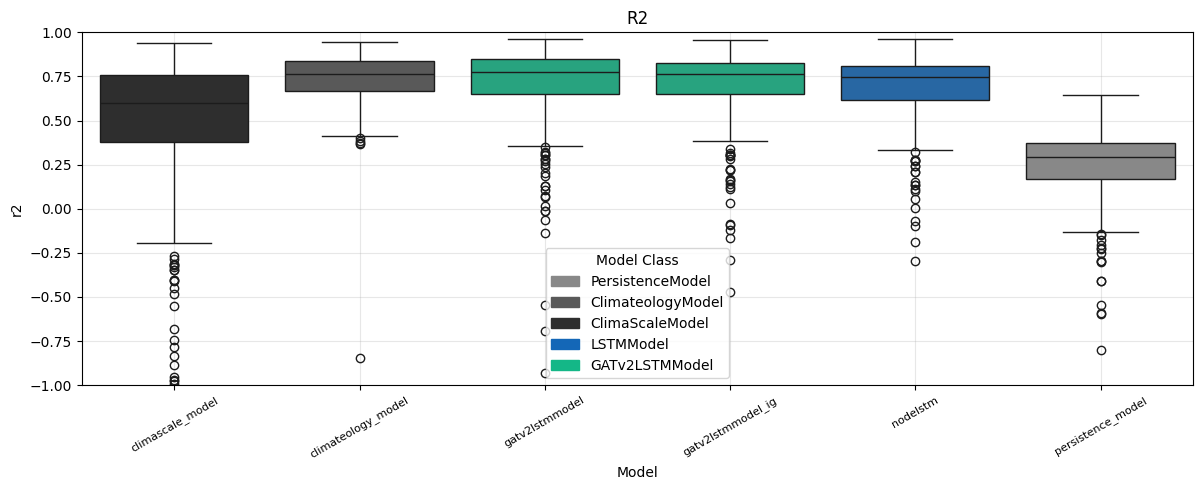

In [30]:
e.plotter.plot_single_metric('r2',0, plot_type='box', log=  False,reverse_scale=True).layout.set_ylim([-1,1]).show()

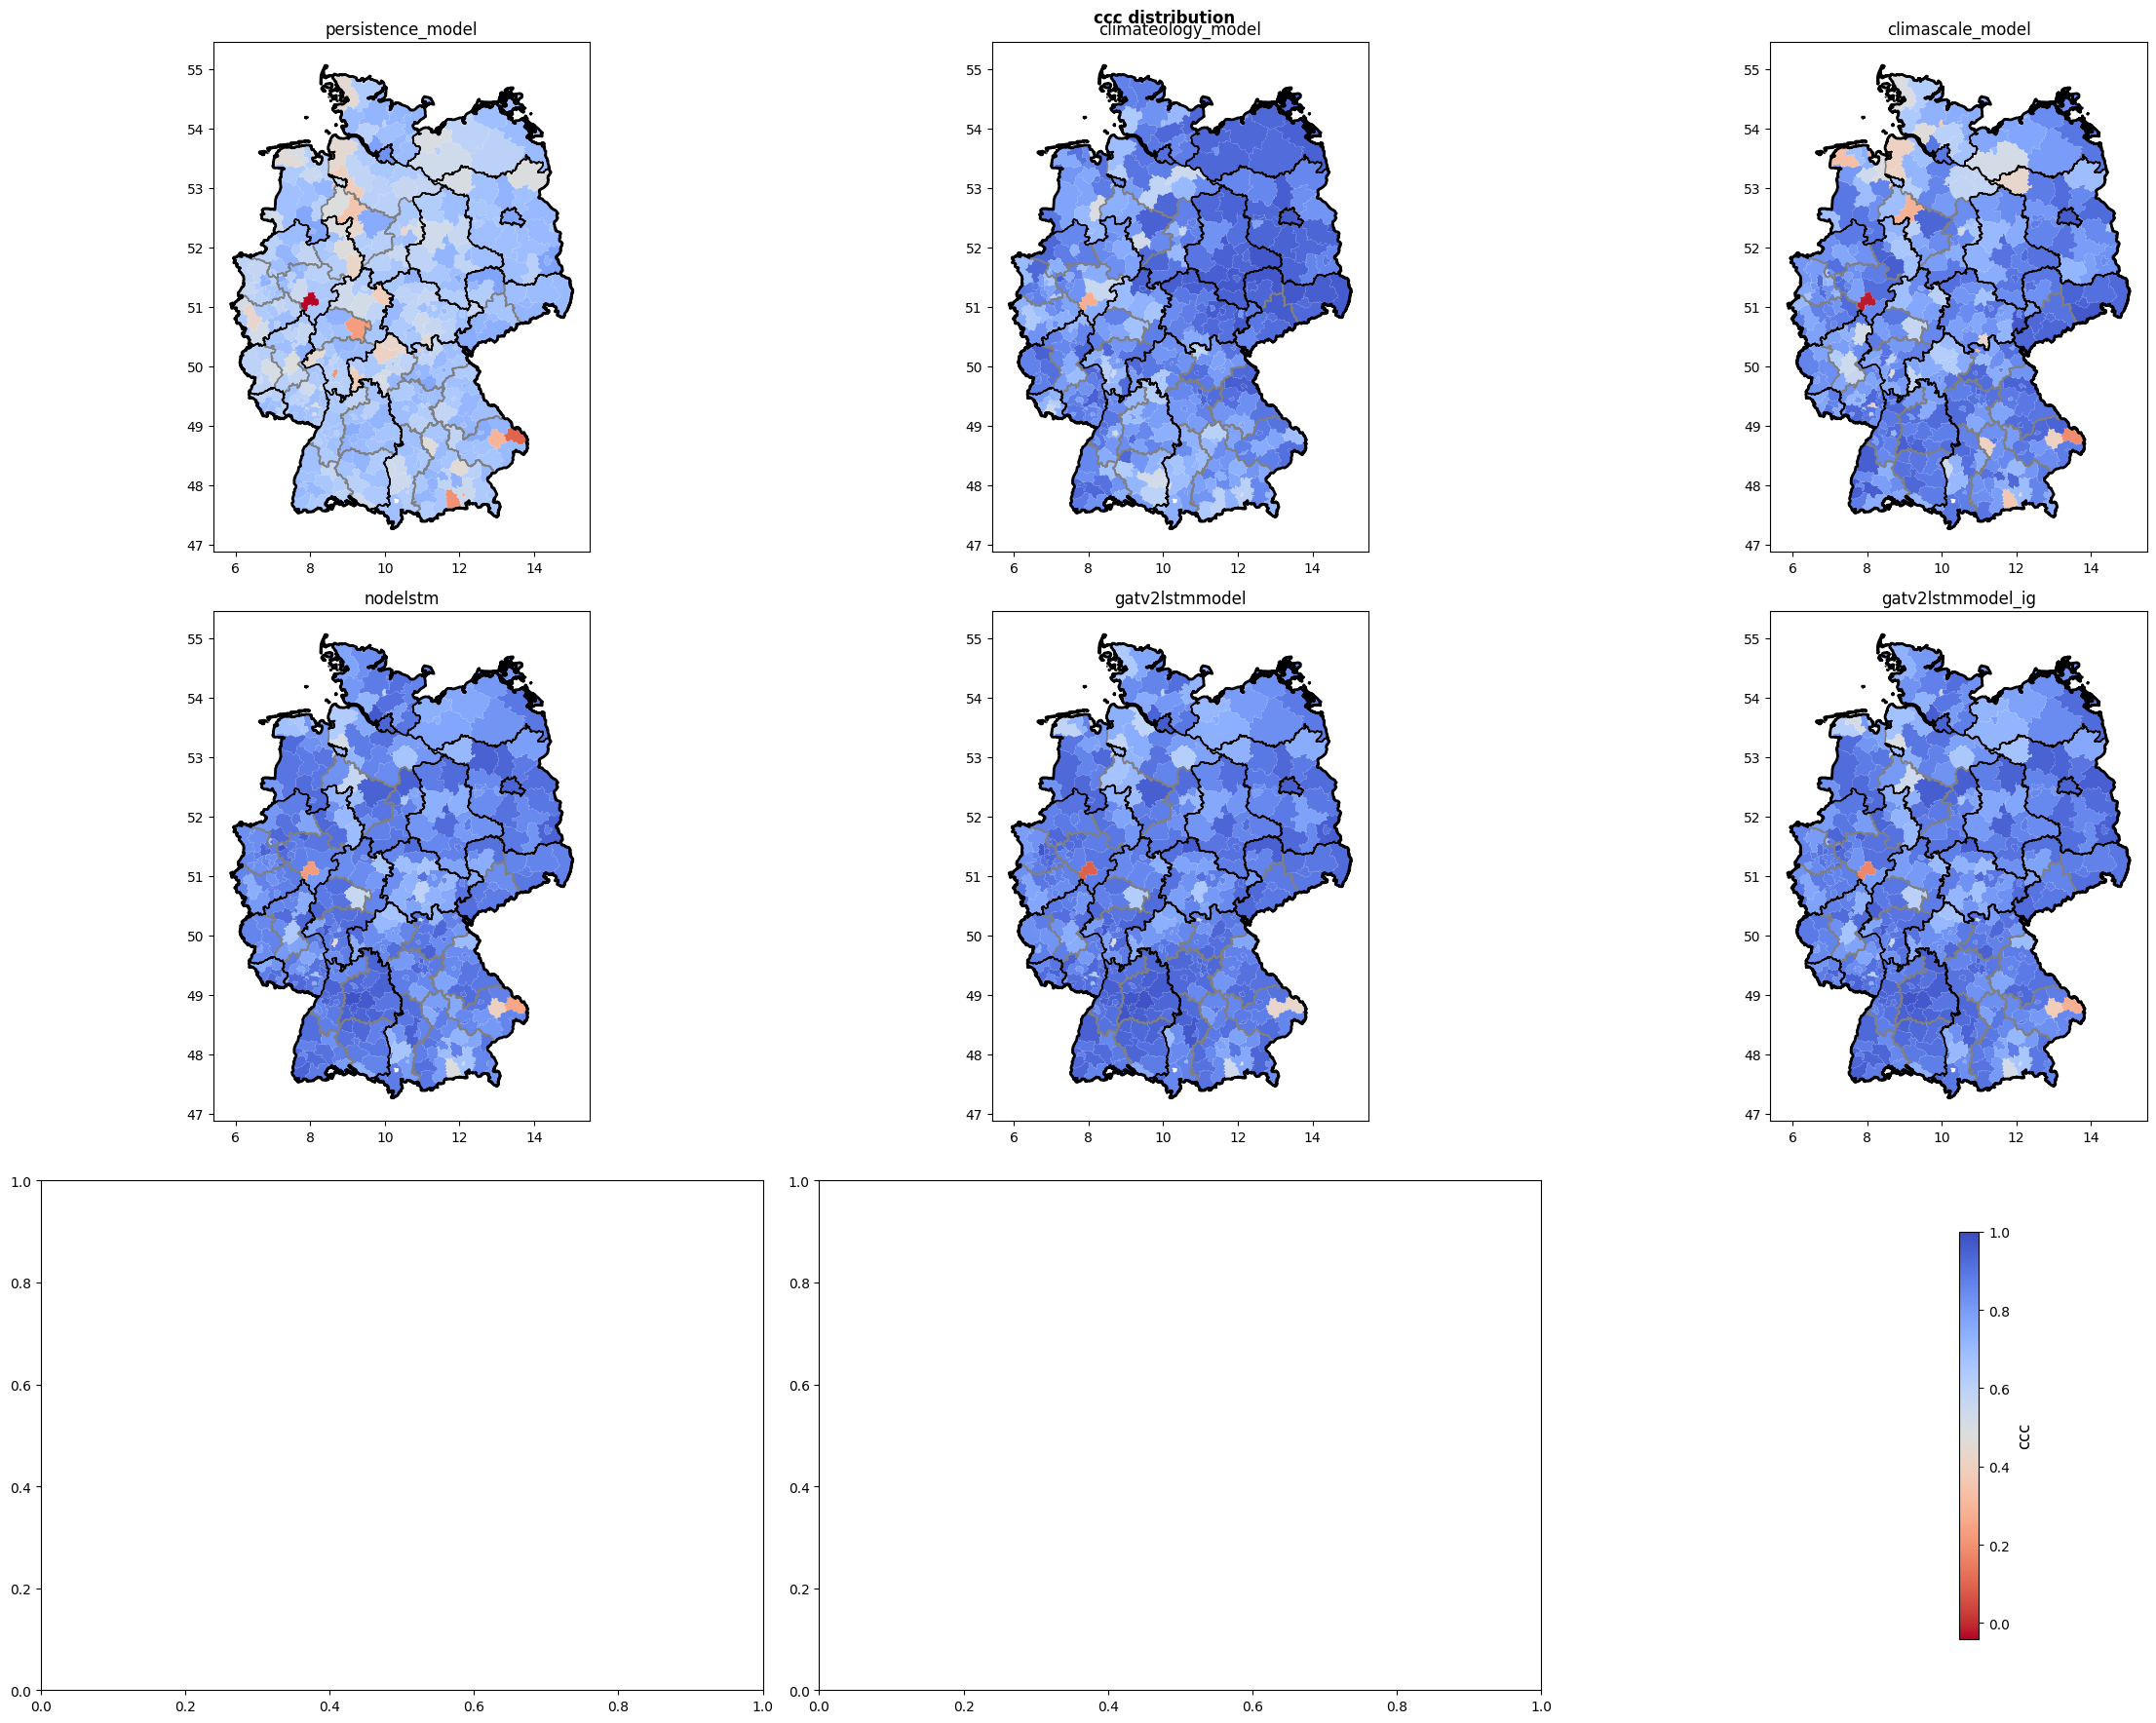

In [26]:
e.plotter.plot_single_metric('ccc',0, plot_type='map', log=  False,reverse_scale=True)